In [1]:
import wandb
import pandas as pd
api = wandb.Api()
runs = api.runs("francisco-soto-u-universidad-de-chile/VICReg-MultipleAugs-LinearCLF-Ablation")
results = []

for run in runs:
    try:
        history = run.history()
        
        if 'val/loss' in history.columns and 'val/f1' in history.columns and 'epoch' in history.columns:
            history_clean = history.dropna(subset=['val/loss', 'val/f1', 'epoch'])
            
            if len(history_clean) == 0:
                continue
            
            # Agrupar por época y tomar el mínimo loss de cada época
            epoch_stats = history_clean.groupby('epoch').agg({
                'val/loss': 'mean',  # Mínimo loss en la época
                'val/f1': 'mean',   # Puedes usar 'mean', 'max', o el valor correspondiente al min loss
                '_step': 'max'      # Último step de la época
            }).reset_index()
            
            # Encontrar la época con el menor loss
            min_loss_epoch_idx = epoch_stats['val/loss'].idxmin()
            best_epoch = epoch_stats.loc[min_loss_epoch_idx]
            
            results.append({
                'run_name': run.name,
                'run_id': run.id,
                'group': run.group if hasattr(run, 'group') else 'default',
                'data.split': run.config.get('data', {}).get('split', None),
                'best_epoch': int(best_epoch['epoch']),
                'min_val_loss': best_epoch['val/loss'],
                'f1_at_min_loss_epoch': best_epoch['val/f1'],
                'total_epochs': int(history_clean['epoch'].max()),
            })
            
    except Exception as e:
        print(f"Error en run {run.name}: {e}")
        continue

# Convertir a DataFrame
results_best_f1s = pd.DataFrame(results)
results_best_f1s = results_best_f1s[results_best_f1s['group'] != 'reduced_size_factor']

print(results_best_f1s)

               run_name    run_id              group  data.split  best_epoch  \
0     prime-firebrand-2  1efntcfr              RN_RS           0          43   
1     blooming-meadow-1  jz7voioh              RN_RS           0          43   
2     youthful-plasma-7  1tur63s8              RN_RS           1          43   
3        prime-shadow-5  8e8du6w2              RN_RS           1          43   
4           solar-sun-4  jviuwto1              RN_RS           0          43   
..                  ...       ...                ...         ...         ...   
120       laced-eon-132  brw5po2f  RN_RS_RM_CS_TS_V2           3          43   
121   logical-field-133  sgzlcihl  RN_RS_RM_CS_TS_V2           1          43   
122    gentle-music-134  0umm3gw1  RN_RS_RM_CS_TS_V2           2          43   
123  twilight-music-135  hty0836a  RN_RS_RM_CS_TS_V2           4          43   
124      lucky-bird-136  63w1qlzj  RN_RS_RM_CS_TS_V2           3          43   

     min_val_loss  f1_at_min_loss_epoch

In [ ]:
# Load the full CSV data
csv_path = '/home/fsoto/Documents/LCsSSL/wandb_csv/augmentations_ablation_v2.csv'
csv = results_best_f1s


csv = csv.rename(columns={'f1_at_min_loss_epoch': 'val/f1'})

# Group by augmentation configuration and calculate mean and std
group_col = 'group'  # Adjust this to your actual group column name
grouped = csv.groupby(group_col)['val/f1'].agg(['mean', 'std', 'count']).reset_index()
grouped = grouped.sort_values(by='mean', ascending=False)
grouped = grouped[grouped[group_col] != 'RN_RS_RM_CS_
                  
                  
                  ouped)
print(f"\nTotal groups: {len(grouped)}")


Grouped Results:
               group      mean       std  count
4  RN_RS_RM_CS_TS_V2  0.673823  0.006338     25
2        RN_RS_RM_CS  0.672541  0.005633     25
1           RN_RS_RM  0.666818  0.004351     25
0              RN_RS  0.656053  0.005090     25

Total groups: 4


In [3]:
results_best_f1s

,run_name,run_id,group,data.split,best_epoch,min_val_loss,f1_at_min_loss_epoch,total_epochs
0,prime-firebrand-2,1efntcfr,RN_RS,0,43,0.979643,0.658443,43
1,blooming-meadow-1,jz7voioh,RN_RS,0,43,0.978701,0.661583,43
2,youthful-plasma-7,1tur63s8,RN_RS,1,43,0.993730,0.659887,43
3,prime-shadow-5,8e8du6w2,RN_RS,1,43,0.993580,0.658603,43
4,solar-sun-4,jviuwto1,RN_RS,0,43,0.986537,0.664282,43
...,...,...,...,...,...,...,...,...
120,laced-eon-132,brw5po2f,RN_RS_RM_CS_TS_V2,3,43,0.928294,0.663702,43
121,logical-field-133,sgzlcihl,RN_RS_RM_CS_TS_V2,1,43,0.912718,0.673542,43
122,gentle-music-134,0umm3gw1,RN_RS_RM_CS_TS_V2,2,43,0.942659,0.677475,43
123,twilight-music-135,hty0836a,RN_RS_RM_CS_TS_V2,4,43,0.922767,0.668825,43


In [4]:
grouped
grouped.to_csv('augmentation_ablation_summary.csv', index=False)

In [5]:
# Perform pairwise permutation tests between all groups
import numpy as np
from mlxtend.evaluate import permutation_test

# Configuration
N_RESAMPLES = 10000
SIGNIFICANCE_LEVEL = 0.05

# Function to get F1 scores for a specific group
def get_f1_scores_for_group(group_value):
    """Get all F1 scores for a specific augmentation group"""
    matching_scores = csv[csv[group_col] == group_value].sort_values(by='data.split')['val/f1'].values
    return np.array(matching_scores)

# Perform pairwise permutation tests
n_groups = len(grouped)
results = []

print(f"PAIRWISE PERMUTATION TEST ANALYSIS")
print(f"=" * 70)
print(f"Number of groups: {n_groups}")
print(f"Total pairwise comparisons: {n_groups * (n_groups - 1) // 2}")
print(f"Resamples: {N_RESAMPLES:,}")
print(f"Significance level: α = {SIGNIFICANCE_LEVEL}")
print(f"\nStarting analysis...\n")

from time import time
start_time = time()

for i in range(n_groups):
    for j in range(i+1, n_groups):
        group_i = grouped.iloc[i][group_col]
        group_j = grouped.iloc[j][group_col]
        
        scores_i = get_f1_scores_for_group(group_i)
        scores_j = get_f1_scores_for_group(group_j)
        
        if len(scores_i) > 1 and len(scores_j) > 1:
            # Perform permutation test
            p_value = permutation_test(
                scores_i, 
                scores_j,
                func='x_mean > y_mean',
                method='approximate',
                num_rounds=N_RESAMPLES,
                paired=True
            )
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt((np.var(scores_i) + np.var(scores_j)) / 2)
            effect_size = (np.mean(scores_i) - np.mean(scores_j)) / pooled_std if pooled_std > 0 else 0
            
            results.append({
                'group_1': group_i,
                'group_2': group_j,
                'mean_f1_1': grouped.iloc[i]['mean'],
                'mean_f1_2': grouped.iloc[j]['mean'],
                'std_f1_1': grouped.iloc[i]['std'],
                'std_f1_2': grouped.iloc[j]['std'],
                'p_value': p_value,
                'significant': p_value < SIGNIFICANCE_LEVEL,
                'effect_size': effect_size,
                'n_samples_1': len(scores_i),
                'n_samples_2': len(scores_j)
            })
            
        if (len(results) % 20 == 0) and len(results) > 0:
            progress = len(results)
            total = n_groups * (n_groups - 1) // 2
            elapsed = time() - start_time
            rate = progress / elapsed if elapsed > 0 else 0
            eta = (total - progress) / rate if rate > 0 else 0
            print(f"  ⚡ {progress:3}/{total} ({100*progress/total:.1f}%) | "
                  f"{rate:.1f} comp/s | ETA: {eta:.0f}s")

comparison_results = pd.DataFrame(results)
elapsed_time = time() - start_time

print(f"\n✓ ANALYSIS COMPLETE in {elapsed_time:.1f}s")
print(f"=" * 70)
print(f"Speed: {len(comparison_results)/elapsed_time:.1f} comparisons/sec")
print(f"Significant: {comparison_results['significant'].sum()}/{len(comparison_results)} "
      f"({100*comparison_results['significant'].sum()/len(comparison_results):.1f}%)")

print(f"\nTOP 5 MOST SIGNIFICANT DIFFERENCES:")
for idx, row in comparison_results[comparison_results['significant']].sort_values('p_value').head(5).iterrows():
    print(f"  {row['group_1']} vs {row['group_2']}: p={row['p_value']:.4f}, d={row['effect_size']:.2f}")

print(f"\n")
comparison_results.head(10)


PAIRWISE PERMUTATION TEST ANALYSIS
Number of groups: 4
Total pairwise comparisons: 6
Resamples: 10,000
Significance level: α = 0.05

Starting analysis...


✓ ANALYSIS COMPLETE in 2.4s
Speed: 2.5 comparisons/sec
Significant: 5/6 (83.3%)

TOP 5 MOST SIGNIFICANT DIFFERENCES:
  RN_RS_RM_CS_TS_V2 vs RN_RS_RM: p=0.0001, d=1.32
  RN_RS_RM_CS_TS_V2 vs RN_RS: p=0.0001, d=3.15
  RN_RS_RM_CS vs RN_RS_RM: p=0.0001, d=1.16
  RN_RS_RM_CS vs RN_RS: p=0.0001, d=3.13
  RN_RS_RM vs RN_RS: p=0.0001, d=2.32



✓ ANALYSIS COMPLETE in 2.4s
Speed: 2.5 comparisons/sec
Significant: 5/6 (83.3%)

TOP 5 MOST SIGNIFICANT DIFFERENCES:
  RN_RS_RM_CS_TS_V2 vs RN_RS_RM: p=0.0001, d=1.32
  RN_RS_RM_CS_TS_V2 vs RN_RS: p=0.0001, d=3.15
  RN_RS_RM_CS vs RN_RS_RM: p=0.0001, d=1.16
  RN_RS_RM_CS vs RN_RS: p=0.0001, d=3.13
  RN_RS_RM vs RN_RS: p=0.0001, d=2.32




,group_1,group_2,mean_f1_1,mean_f1_2,std_f1_1,std_f1_2,p_value,significant,effect_size,n_samples_1,n_samples_2
0,RN_RS_RM_CS_TS_V2,RN_RS_RM_CS,0.673823,0.672541,0.006338,0.005633,0.170483,False,0.218145,25,25
1,RN_RS_RM_CS_TS_V2,RN_RS_RM,0.673823,0.666818,0.006338,0.004351,0.000100,True,1.315112,25,25
2,RN_RS_RM_CS_TS_V2,RN_RS,0.673823,0.656053,0.006338,0.005090,0.000100,True,3.154983,25,25
3,RN_RS_RM_CS,RN_RS_RM,0.672541,0.666818,0.005633,0.004351,0.000100,True,1.160535,25,25
4,RN_RS_RM_CS,RN_RS,0.672541,0.656053,0.005633,0.005090,0.000100,True,3.134392,25,25
5,RN_RS_RM,RN_RS,0.666818,0.656053,0.004351,0.005090,0.000100,True,2.320325,25,25


In [6]:
# Export results to CSV
output_path = '/home/fsoto/Documents/LCsSSL/wandb_csv/augmentation_ablation_results.csv'

# Create summary with mean ± std format
summary_results = []
for i in range(n_groups):
    group_value = grouped.iloc[i][group_col]
    
    # Count how many groups this one is significantly better than
    sig_better = comparison_results[
        (comparison_results['group_1'] == group_value) &
        (comparison_results['significant'] == True) &
        (comparison_results['effect_size'] > 0)
    ]
    
    summary_results.append({
        'Rank': i + 1,
        'Augmentation': group_value,
        'F1_Mean': grouped.iloc[i]['mean'],
        'F1_Std': grouped.iloc[i]['std'],
        'Count': int(grouped.iloc[i]['count']),
        'Num_Significantly_Better_Than': len(sig_better)
    })

summary_df = pd.DataFrame(summary_results)
summary_df.to_csv(output_path, index=False, float_format='%.6f')

print(f"✓ Summary results saved to: {output_path}")
print(f"  Rows: {len(summary_df)}")
print(f"\nSummary:")
print(summary_df.to_string(index=False))

# Also save detailed pairwise comparisons
detailed_output_path = '/home/fsoto/Documents/LCsSSL/wandb_csv/augmentation_ablation_pairwise.csv'
comparison_results.to_csv(detailed_output_path, index=False, float_format='%.6f')
print(f"\n✓ Detailed pairwise comparisons saved to: {detailed_output_path}")


✓ Summary results saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/augmentation_ablation_results.csv
  Rows: 4

Summary:
 Rank      Augmentation  F1_Mean   F1_Std  Count  Num_Significantly_Better_Than
    1 RN_RS_RM_CS_TS_V2 0.673823 0.006338     25                              2
    2       RN_RS_RM_CS 0.672541 0.005633     25                              2
    3          RN_RS_RM 0.666818 0.004351     25                              1
    4             RN_RS 0.656053 0.005090     25                              0

✓ Detailed pairwise comparisons saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/augmentation_ablation_pairwise.csv


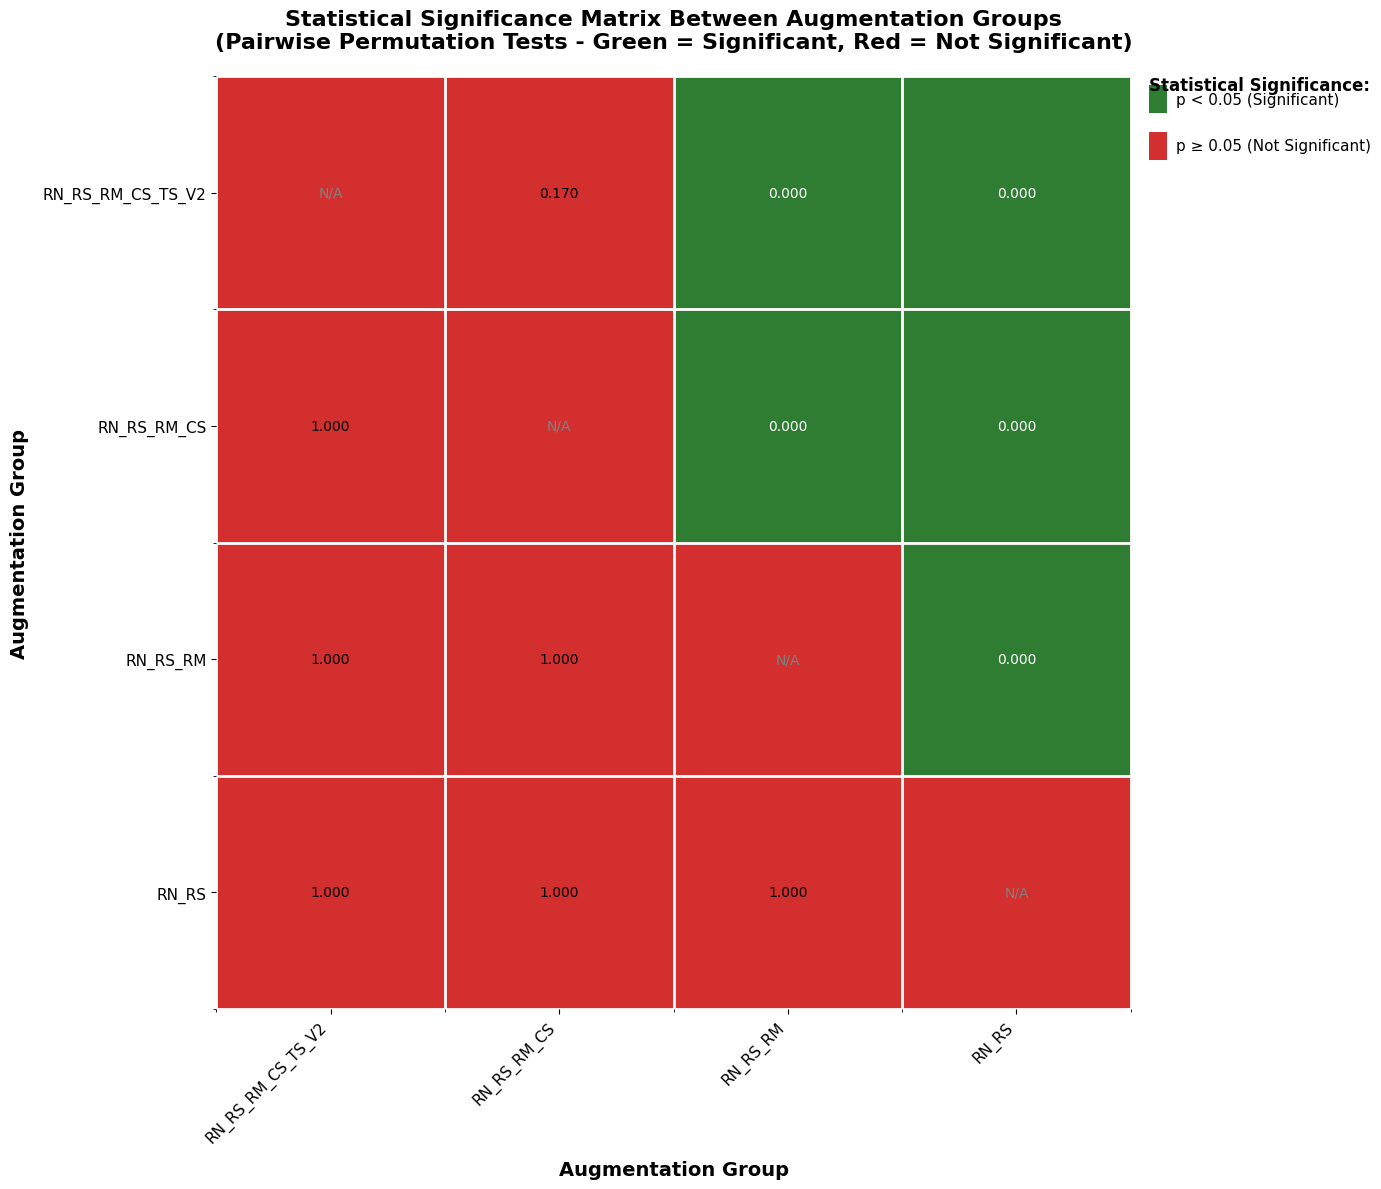


✓ Significance matrix plot saved to: augmentation_significance_matrix.png


In [7]:
# Create significance matrix (confusion matrix style)
import matplotlib.pyplot as plt
import seaborn as sns

# Create p-value matrix
p_value_matrix = np.ones((n_groups, n_groups))

# Create a mapping from group names to indices
group_names = [grouped.iloc[i][group_col] for i in range(n_groups)]

for _, row in comparison_results.iterrows():
    i = group_names.index(row['group_1'])
    j = group_names.index(row['group_2'])
    p_value_matrix[i, j] = row['p_value']

# Create the heatmap
fig, ax = plt.subplots(1, 1, figsize=(14, 12), facecolor='white')

# Create binary significance matrix for visualization
significance_matrix = (p_value_matrix < SIGNIFICANCE_LEVEL).astype(int)

# Use a custom colormap: red for not significant, green for significant
colors = ['#D32F2F', '#2E7D32']  # Red, Green
cmap = plt.matplotlib.colors.ListedColormap(colors)

# Plot the heatmap
im = ax.imshow(significance_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add p-value annotations
for i in range(n_groups):
    for j in range(n_groups):
        if i != j:
            # Choose text color based on background
            text_color = 'white' if significance_matrix[i, j] == 1 else 'black'
            ax.text(j, i, f'{p_value_matrix[i, j]:.3f}',
                   ha='center', va='center',
                   fontsize=10,
                   color=text_color,
                   fontweight='500')
        else:
            # Diagonal - mark as N/A
            ax.text(j, i, 'N/A',
                   ha='center', va='center',
                   fontsize=10,
                   color='gray',
                   fontweight='500')

# Set ticks and labels
ax.set_xticks(range(n_groups))
ax.set_yticks(range(n_groups))
ax.set_xticklabels(group_names, rotation=45, ha='right', fontsize=11, fontweight='500')
ax.set_yticklabels(group_names, fontsize=11, fontweight='500')

# Labels and title
ax.set_xlabel('Augmentation Group', fontsize=14, fontweight='600', labelpad=10)
ax.set_ylabel('Augmentation Group', fontsize=14, fontweight='600', labelpad=10)
ax.set_title('Statistical Significance Matrix Between Augmentation Groups\n(Pairwise Permutation Tests - Green = Significant, Red = Not Significant)',
             fontsize=16, pad=20, fontweight='bold')

# Add grid
ax.set_xticks(np.arange(-0.5, n_groups, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_groups, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add colorbar legend
from matplotlib.patches import Rectangle
legend_labels = [
    f'p < {SIGNIFICANCE_LEVEL} (Significant)',
    f'p ≥ {SIGNIFICANCE_LEVEL} (Not Significant)'
]
legend_colors = ['#2E7D32', '#D32F2F']

ax.text(1.02, 1.0, "Statistical Significance:", transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

for i, (color, label) in enumerate(zip(legend_colors, legend_labels)):
    y_pos = 0.96 - i * 0.05
    rect = Rectangle((1.02, y_pos), 0.02, 0.03,
                     facecolor=color, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(1.05, y_pos + 0.015, label,
            transform=ax.transAxes, fontsize=11, va='center', ha='left',
            fontweight='500')

plt.tight_layout()
plt.savefig('/home/fsoto/Documents/LCsSSL/wandb_csv/augmentation_significance_matrix.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Significance matrix plot saved to: augmentation_significance_matrix.png")
